# Reliable ABC model choice via random forests (Pudlo et al., 2015)
**Computational Statistics (MVA 2025-2026)**  


**Student:** Yannaël Bossard
**Email:** yannael.bossard@ens-paris-saclay.fr  
**Student:** Amaury de Vitry
**Email:** devitry.amaury@gmail.com

**Project Deadline:** 06 / 01 / 2026



### Objective:
This notebook aimes to re-implement the framework ABC-RF proposed by Pudlo et al. (2015). It consists ..

Studied paper: 10.1093/bioinformatics/btv684
Source code: https://github.com/jmm34/abcrf/tree/main


### summary:
1.   mock dataset
2.   Algorithm 2 + 3
3.   Mock test of ABC-RF
4.   Hand-made Computational Neuroscience Benchmark
5.   aaa...






### Libraries

In [ ]:
from logging import debug
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.patches
import warnings
from sklearn.manifold import TSNE
import os
import sys
import random
import pandas as pd
import seaborn as sns



def set_seed(seeed=13):
    #random.seed(seeed)
    np.random.seed(seeed)

    #torch.manual_seed(seed)
    #torch.cuda.manual_seed(seed)
    #torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seeed)

    #torch.backends.cudnn.deterministic = True
    #torch.backends.cudnn.benchmark = False

seeed = 13
set_seed(seeed)

## Generate mock Reference Table


In [ ]:
def generate_mock_ref_table(n_sim,n_model,n_features,):
  '''
  aa
  '''

  reference_data = []
  labels = []

  for _ in range(n_sim):
    m = np.random.choice(range(n_model)) # Sample model from uniform Prior

    stats =   np.random.normal(m, 1, n_features) # Model 'm' stats

    reference_data.append(stats)
    labels.append(m)
  return np.array(reference_data), np.array(labels)

#X_ref, y_ref = generate_mock_ref_table(n_sim=5,n_model=3,n_features=4)


def generate_mock_obs_table(n_obs,i_model,n_features):
  '''
  aa
  '''

  reference_data = []
  labels = []

  m = i_model
  for _ in range(n_obs):

    stats = np.random.normal(m, 1, n_features) # Model 'm' stats

    reference_data.append(stats)
    labels.append(m)

  return np.array(reference_data), np.array(labels)



# Algo 2: ABC-RF with selected model as the majority elected by the classifier



In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier


def train_ABCRF_classifier(X_ref, y_ref,n_trees=500,seed=13):
  '''
  Model choice: Train ABCRF classifier on simulation
    Function defined by algorithm 2 in the Pudlo et al.
  '''

  # Fit LDA on Reference Table (cf Sec.3.2 of Pudlo et al.)
  lda = LinearDiscriminantAnalysis(n_components=None) # default is n_classes-1
  lda.fit(X_ref, y_ref)
  lda_features_ref = lda.transform(X_ref)
  X_ref_augmented = np.hstack([X_ref, lda_features_ref]) # Complement the Reference Table

  # Train RF
  rf_classifier = RandomForestClassifier(n_estimators=n_trees, oob_score=True, random_state=seed)
  rf_classifier.fit(X_ref_augmented, y_ref)

  return rf_classifier, lda




def predict_ABCRF_classifier(rf_classifier, lda, X_obs,verbose=False):
  '''
  Model choice: Predict model using the trained ABCRF classifier on simulation
    Function defined by algorithm 2 in the Pudlo et al.
  '''

  lda_features_obs = lda.transform(X_obs)
  X_obs_augmented = np.hstack([X_obs, lda_features_obs])
  n_obs = X_obs.shape[0]

  # Get the majority vote (Selected Model)
  predicted_model = rf_classifier.predict(X_obs_augmented) # (n_obs)

  # Get vote proportion
  vote_proportions = rf_classifier.predict_proba(X_obs_augmented) # shape (n_model,n_obs)
  n_trees = rf_classifier.n_estimators
  vote_counts = (vote_proportions * n_trees).astype(int)

  if n_obs > 1: # Functionb useful for CompNeuro benchmark, explain later in the notebook
    unique, counts = np.unique(predicted_model,return_counts=True)
    argmax = np.argmax(counts)
    selected_model = unique[argmax]
    votes = np.mean(vote_counts[:,selected_model])
    rate_agreement = counts[argmax]/n_obs

    if verbose:
      print(f"Selected Model: {selected_model}, true model = {y_obs[0]}")
      print(f"Vote Counts: {votes} out of {n_trees}")

    if verbose and False:
      for i in range(n_obs):
        print(f"\n For observation {i+1}:")
        indi_votes = vote_counts[i]
        indi_selected_model = predicted_model[i]
        print(f"Selected Model: {indi_selected_model}, true model = {y_obs[0]}")
        print(f"Vote Counts: {indi_votes} out of {n_trees}")

  else: # Default move in the ABC-RF paper
    votes = vote_counts[0]
    selected_model = predicted_model[0]
    rate_agreement = 1
    if verbose:
      print(f"Selected Model: {selected_model}, true model = {y_obs[0]}")
      print(f"Vote Counts: {votes} out of {n_trees}")

  return selected_model, votes, rate_agreement



# Algo 3: Estimating the posterior probability of the selected model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def compute_oob_error_indicator(rf_classifier, X_ref_aug, y_ref):
    """
    Step (a) Algorithm 3
    Compute binary prediction error using OOB predictions
    """
    oob_pred = rf_classifier.oob_decision_function_.argmax(axis=1)
    error_indicator = (oob_pred != y_ref).astype(int)
    return error_indicator

def train_error_rf_regressor(X_ref, y_ref, rf_classifier, fitted_lda,
                             n_trees=500, seed=13):
    """
    Step (b) Algorithm 3
    RF regression of the classification error
    """
    lda_features_ref = fitted_lda.transform(X_ref)
    X_ref_augmented = np.hstack([X_ref, lda_features_ref]) # Complement the Reference Table
    error_indicator = compute_oob_error_indicator(rf_classifier, X_ref_augmented, y_ref)
    rf_reg = RandomForestRegressor(n_estimators=n_trees,random_state=seed,oob_score=True)
    rf_reg.fit(X_ref_augmented, error_indicator)
    return rf_reg


def estimate_posterior_probability(
    rf_classifier,
    rf_regressor,
    lda,
    X_obs
):
    """
    Step (c) Algorithm 3
    """
    lda_features_obs = lda.transform(X_obs)
    X_obs_aug = np.hstack([X_obs, lda_features_obs])

    error_pred = rf_regressor.predict(X_obs_aug)
    posterior_prob = 1.0 - error_pred

    return posterior_prob


def RF_regressor():
  '''
  Parameters inference:
    Function defined by algorithm 3 in the Pudlo et al.
  '''
  pass

  return None

# Algo 0: Standard ABC algorithm

Need to implement standard ABC algo for comparison of performance on our benchamrks

And/Or MCMC-ABC

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.spatial.distance import euclidean

def ABC_knn_algo(
    X_ref,
    y_ref,
    X_obs,
    y_obs=None,
    n_accept=1000,
    scale=True
):
    '''
    Classical ABC (rejection / k-NN) for model choice
    - Posterior: mean over observations (unchanged)
    - Decision: majority vote over individual MAP predictions
    - Error rate: if y_obs provided
    '''

    # ---------- Standardization ----------
    if scale:
        scaler = StandardScaler()
        X_ref_scaled = scaler.fit_transform(X_ref)
        X_obs_scaled = scaler.transform(X_obs)
    else:
        X_ref_scaled = X_ref
        X_obs_scaled = X_obs

    models = np.unique(y_ref)
    posterior_accumulator = {m: [] for m in models}
    individual_predictions = []

    # ---------- Loop over observations ----------
    for i in range(X_obs_scaled.shape[0]):

        x0 = X_obs_scaled[i:i+1]

        distances = cdist(X_ref_scaled, x0, metric="euclidean").flatten()
        accepted_idx = np.argsort(distances)[:n_accept]
        accepted_models = y_ref[accepted_idx]

        unique, counts = np.unique(accepted_models, return_counts=True)
        posterior_i = {m: 0.0 for m in models}
        for m, c in zip(unique, counts):
            posterior_i[m] = c / n_accept

        # Store posterior
        for m in models:
            posterior_accumulator[m].append(posterior_i[m])

        # Individual MAP prediction
        individual_predictions.append(
            max(posterior_i, key=posterior_i.get)
        )

    # ---------- Aggregate posterior (unchanged) ----------
    posterior_probs = {
        m: np.mean(posterior_accumulator[m])
        for m in models
    }

   # ---------- Majority vote (robust) ----------
    individual_predictions = np.array(individual_predictions)
    unique_models, counts = np.unique(individual_predictions, return_counts=True)
    selected_model = unique_models[np.argmax(counts)]


    # ---------- Error rate ----------
    # YB to AdV: What is that ? It's not comparable to rate agreement
    error_rate = None
    if y_obs is not None:
        error_rate = np.mean(individual_predictions == y_obs)


    n_obs = len(individual_predictions)
    if n_obs<=1:
      rate_agreement = 1
    else:
      rate_agreement = max(counts)/len(individual_predictions)

    return selected_model, posterior_probs, rate_agreement

def ABC_MCMC_algo(
    X_ref,
    y_ref,
    X_obs,
    y_obs=None,
    n_steps=20000,
    epsilon=0.5,
    scale=True,
    seed=13
):
    '''
    Classical ABC-MCMC for model choice
    - Posterior: mean over observations (unchanged)
    - Decision: majority vote over individual MAP predictions
    - Error rate: if y_obs provided
    '''

    rng = np.random.default_rng(seed)

    # ---------- Standardization ----------
    if scale:
        scaler = StandardScaler()
        X_ref_scaled = scaler.fit_transform(X_ref)
        X_obs_scaled = scaler.transform(X_obs)
    else:
        X_ref_scaled = X_ref
        X_obs_scaled = X_obs

    models = np.unique(y_ref)
    model_to_indices = {
        m: np.where(y_ref == m)[0]
        for m in models
    }

    posterior_accumulator = {m: [] for m in models}
    individual_predictions = []

    # ---------- Loop over observations ----------
    for i in range(X_obs_scaled.shape[0]):

        x0 = X_obs_scaled[i]

        current_model = rng.choice(models)
        current_idx = rng.choice(model_to_indices[current_model])
        current_stat = X_ref_scaled[current_idx]

        chain = []

        for _ in range(n_steps):

            proposed_model = rng.choice(models)
            proposed_idx = rng.choice(model_to_indices[proposed_model])
            proposed_stat = X_ref_scaled[proposed_idx]

            if euclidean(proposed_stat, x0) <= epsilon:
                current_model = proposed_model
                current_stat = proposed_stat

            chain.append(current_model)

        chain = np.array(chain)

        unique, counts = np.unique(chain, return_counts=True)
        posterior_i = {m: 0.0 for m in models}
        for m, c in zip(unique, counts):
            posterior_i[m] = c / len(chain)

        # Store posterior
        for m in models:
            posterior_accumulator[m].append(posterior_i[m])

        # Individual MAP prediction
        individual_predictions.append(
            max(posterior_i, key=posterior_i.get)
        )

    # ---------- Aggregate posterior (unchanged) ----------
    posterior_probs = {
        m: np.mean(posterior_accumulator[m])
        for m in models
    }

    # ---------- Majority vote (robust) ----------
    individual_predictions = np.array(individual_predictions)
    unique_models, counts = np.unique(individual_predictions, return_counts=True)
    selected_model = unique_models[np.argmax(counts)]

    # ---------- Error rate ----------
    error_rate = None
    if y_obs is not None:
        error_rate = np.mean(individual_predictions == y_obs)

    n_obs = len(individual_predictions)
    if n_obs<=1:
      rate_agreement = 1
    else:
      rate_agreement = max(counts)/len(individual_predictions)

    return selected_model, posterior_probs, rate_agreement


# Mock test

Test our ABC-RF implementation on very basic test

In [ ]:
n_model, n_features = 3, 4
# Training data
X_ref, y_ref = generate_mock_ref_table(n_sim=1000,n_model=n_model,n_features=n_features)

# Observed data
X_obs,y_obs = generate_mock_obs_table(n_obs=3,i_model=0.8,n_features=n_features)


# Train
n_trees=500
rf_model, fitted_lda = train_ABCRF_classifier(X_ref, y_ref,n_trees=n_trees)

# Train Regressor
rf_reg = train_error_rf_regressor(X_ref, y_ref, rf_model, fitted_lda, n_trees=n_trees, seed=13)


# Predict
selected_model, votes, rate_agreement = predict_ABCRF_classifier(rf_model, fitted_lda, X_obs)
posterior_prob = estimate_posterior_probability(rf_model, rf_reg, fitted_lda, X_obs)

# Benchmark
selected_model_knn, posterior_probs_knn, error_rate_knn = ABC_knn_algo(X_ref, y_ref, X_obs)
selected_model_mcm, posterior_probs_mcm, error_rate_mcmc = ABC_MCMC_algo(X_ref, y_ref, X_obs)


## I- Computational Neuroscience Benchmarks

#### Network Connectivity (Graph Theory):
**Goal:** Infer the topology of a neural network based purely on the rasterplot (binary neural activity across time)

**Method:** Use NetworkX to generate the connectivity matrix A, then simulate the neuronal dynamics using Brian2 with N neurons connected by A.

**Summary Statistics:** (use of Elephant)

*   Mean firing rate (Hz) across all neurons
*   Population Fanofactor
*   CV factor
*   Lv factor
*   Mean Pairwise Correlation


**Resources:**

0.   ABC-RF is implemented using sklearn.ensemble built-in functions
1.   Graph are generated using built-in NetworkX function
2.   Neural network simulation is run via Brian2 (https://brian2.readthedocs.io/en/stable/examples/frompapers.Brette_Gerstner_2005.html)
3.   Summary statistics are computed via Elephant package ( https://elephant.readthedocs.io/en/latest/modules.html)


In [ ]:
import networkx as nx
try:
  from brian2 import *
except:
  !pip install brian2
  from brian2 import *


In [ ]:
# Network Topology Generators (NetworkX)
def generate_topology(model_idx, N=100, var_magn=0):
  '''
  Generate the connectivity matrix for a specific graph model.
  (Graph generation: https://networkx.org/documentation/stable/reference/generated/networkx.generators.classic.complete_graph.html)

  Returns a list of edges (source, target)
  '''

  if model_idx == 0: # Random Network with bionomial connectivity (Erdos-Renyi)
    G = nx.erdos_renyi_graph(n=N, p=0.1+0.1*np.random.uniform(-var_magn, var_magn),directed=True)

  elif model_idx == 3: # Small-World with k-neighbors connection in a ring (Watts-Strogatz)
    varia = np.random.uniform(-var_magn, var_magn)
    G = nx.connected_watts_strogatz_graph(n=N, k=10+int(20*varia), p=0.05+0.05*varia)

  elif model_idx == 8: # Hub structure with roots (Barabasi-Albert)
    varia = np.random.uniform(-var_magn, var_magn)
    G = nx.barabasi_albert_graph(n=N, m=5+int(10*varia))

  elif model_idx == 4: # scale_free_graph
    G = nx.scale_free_graph(n=N)

  elif model_idx == 2: # Complete Graph
    G = nx.complete_graph(n=N)

  elif model_idx == 6: # waxman_graph
    G = nx.waxman_graph(n=N)

  elif model_idx == 1: # full_rary_tree
    G = nx.full_rary_tree(r=N//15, n=N)

  elif model_idx == 5: # wheel_graph
    G = nx.wheel_graph(n=N)

  elif model_idx == 7: # random_regular_graph
    G = nx.random_regular_graph(d=12, n=N)

  else:
    raise ValueError("Unknown model index, not implemented yet ...")


  edges = list(G.edges()) # Convert NetworkX graph to list of edges for Brian2
  return edges


def plot_network_graph(edges, N, idx_exci):
  '''
  Plots the directed graph of the neural network.
  Blue nodes = Excitatory, Red nodes = Inhibitory
  '''
  # Create a Directed Graph
  G = nx.DiGraph()
  G.add_nodes_from(range(N))
  G.add_edges_from(edges)

  node_colors = []
  exci_set = set(idx_exci) if idx_exci is not None else set()

  for node in G.nodes():
    if node in exci_set:
      node_colors.append('blue') # Excitatory
    else:
      node_colors.append('red') # Inhibitory


  # Get a Layout. One could use the DeepLPBM algo we developped in PGM
  pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

  plt.figure(figsize=(8, 8))
  nx.draw_networkx_nodes(G, pos, node_size=50,node_color=node_colors,alpha=0.8)
  nx.draw_networkx_edges(G, pos, width=0.5,alpha=0.3, arrowstyle='->', arrowsize=10, edge_color='gray')
  plt.title(f"Network Topology (N={N}, Connections={len(edges)})")
  plt.axis('off')
  plt.show()

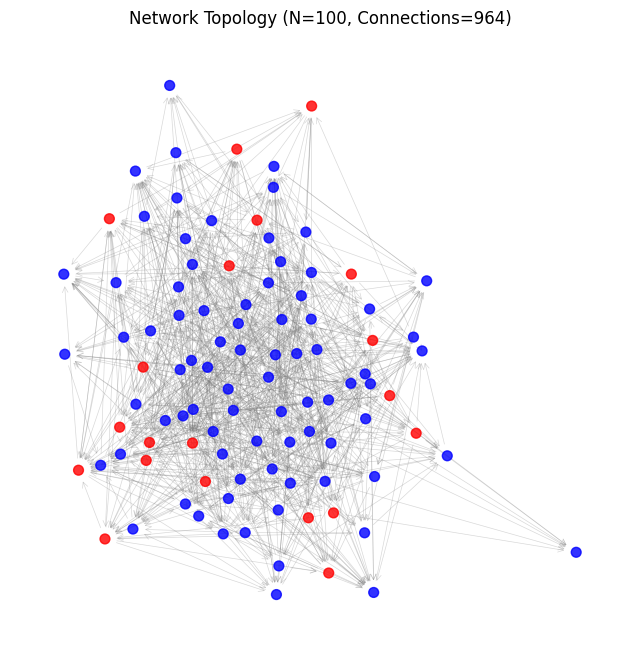

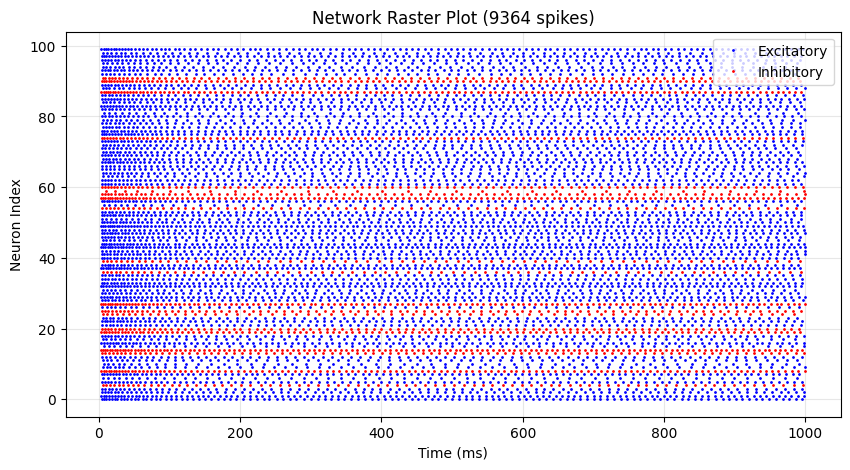

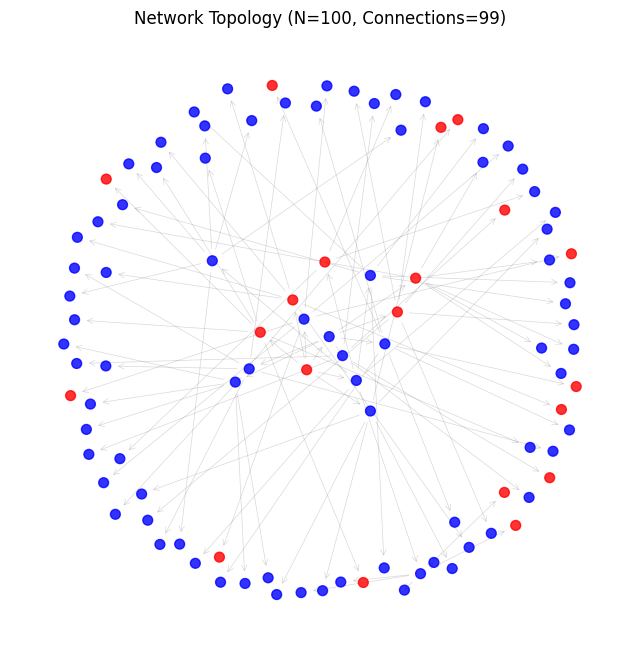

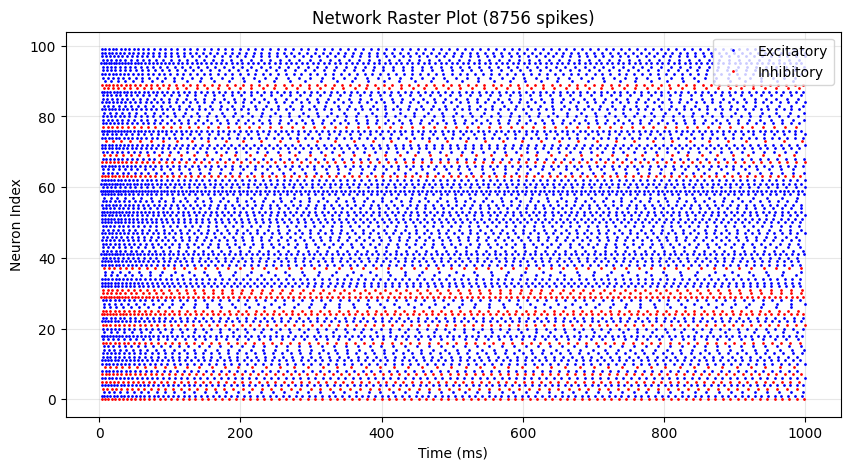

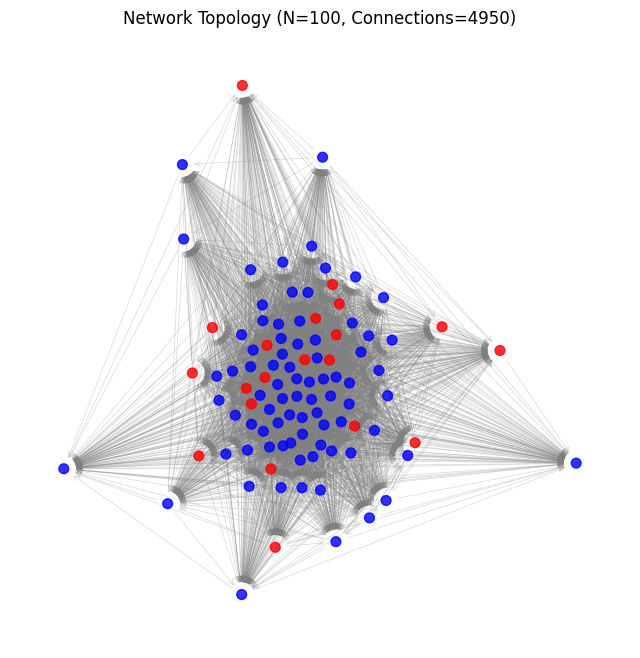

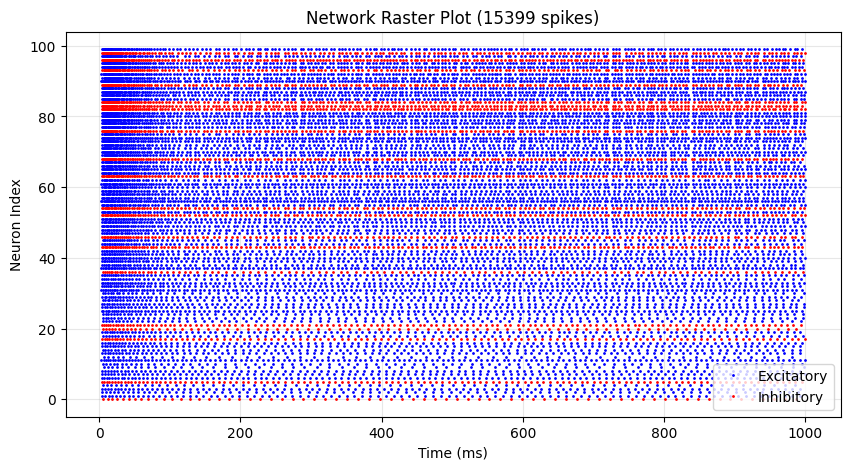

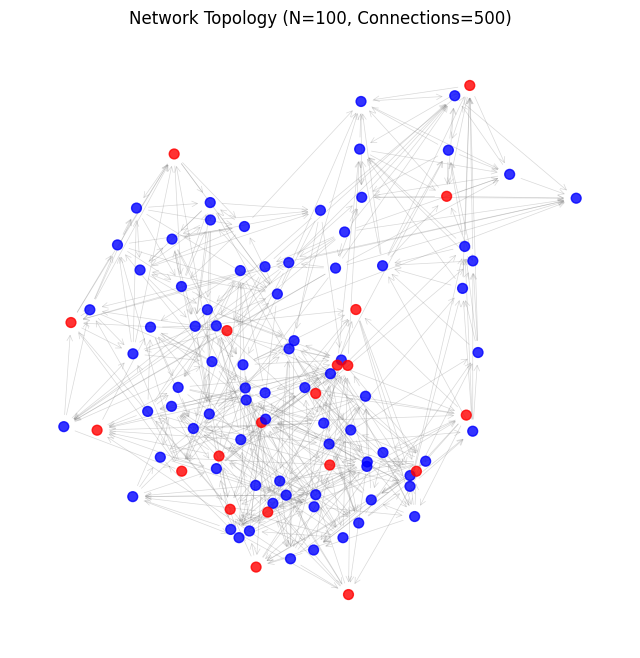

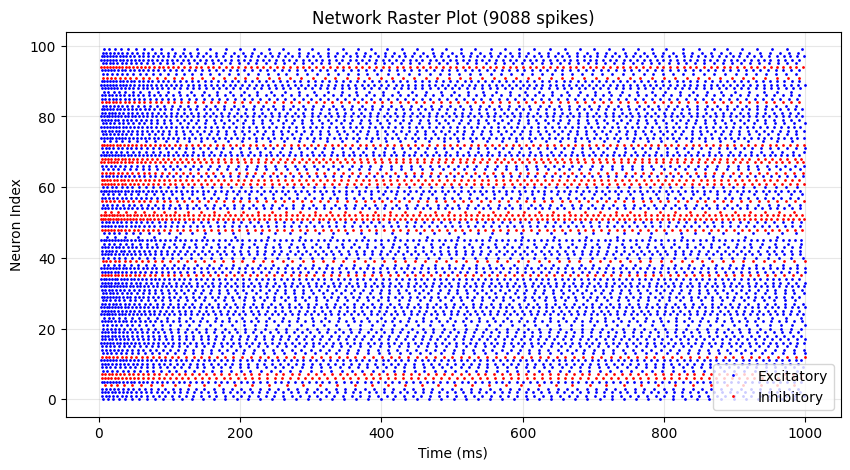

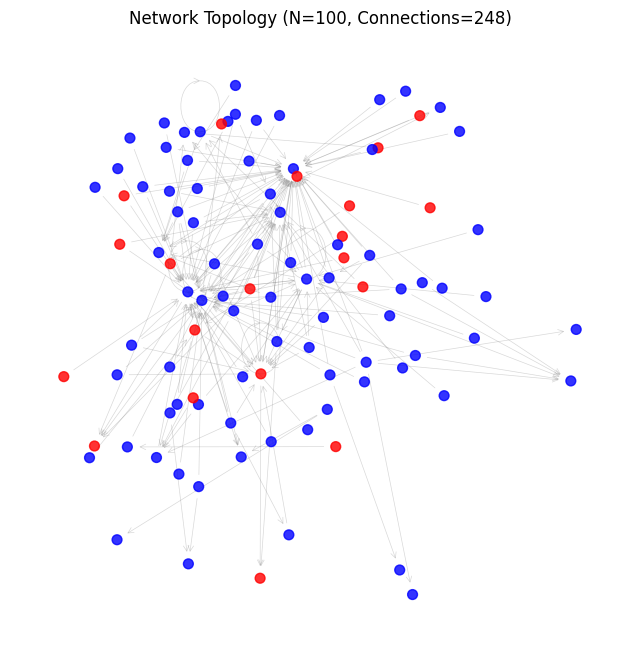

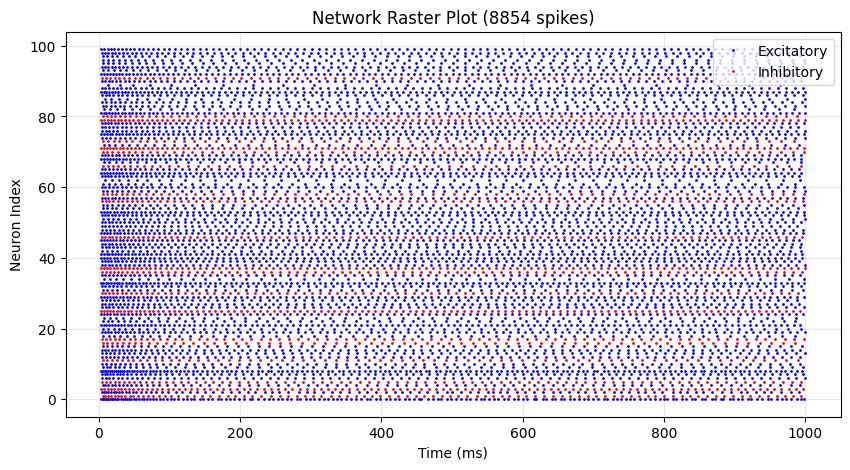

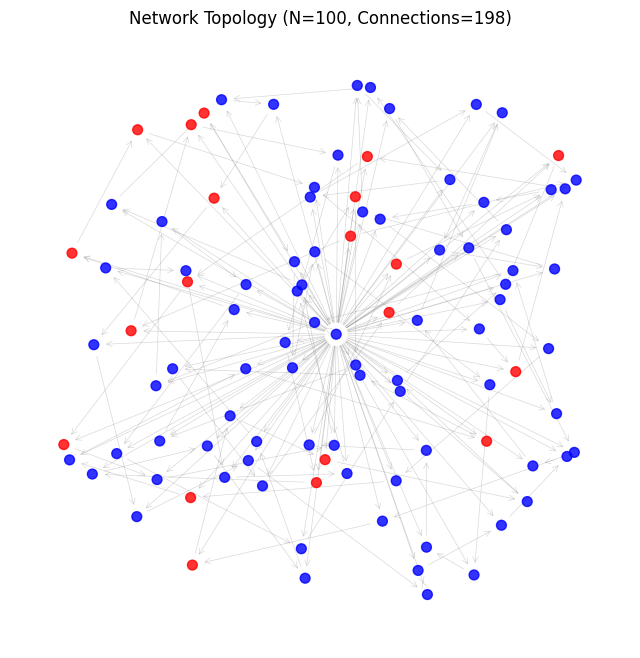

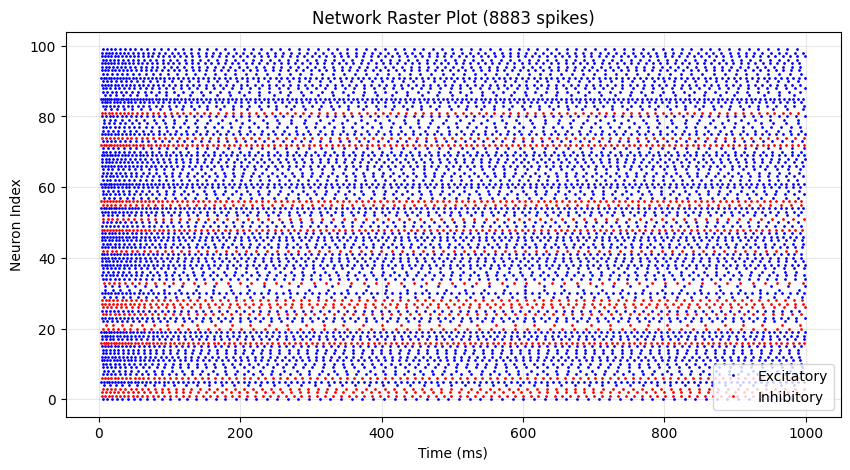

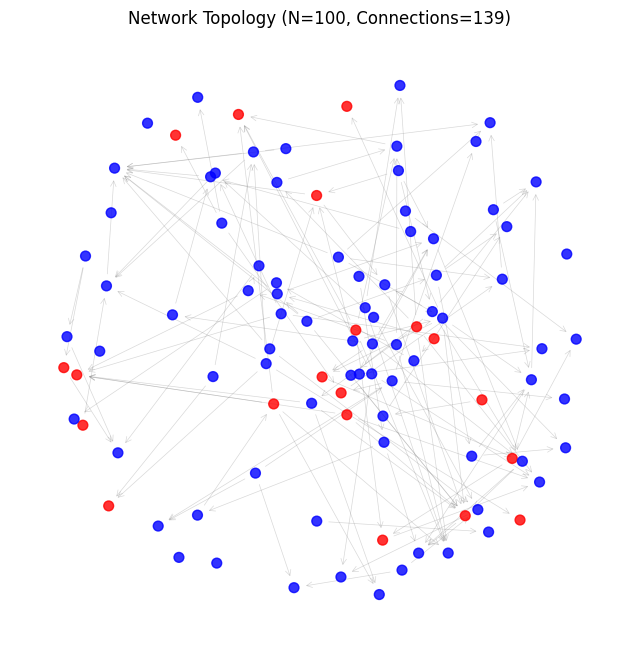

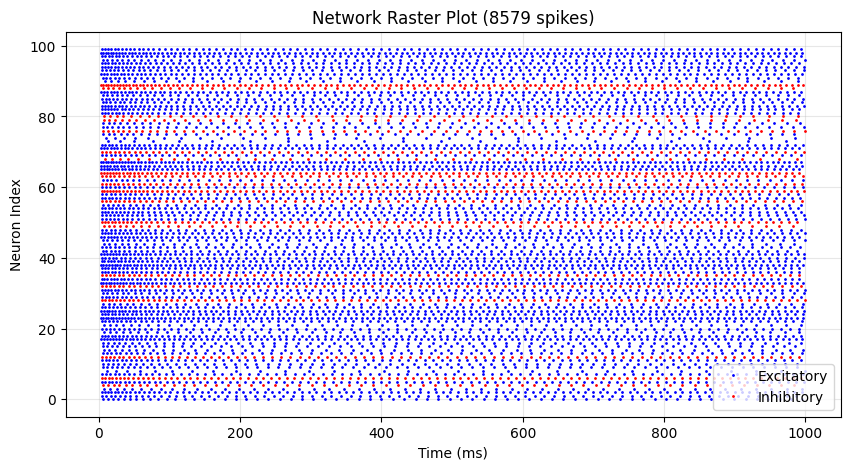

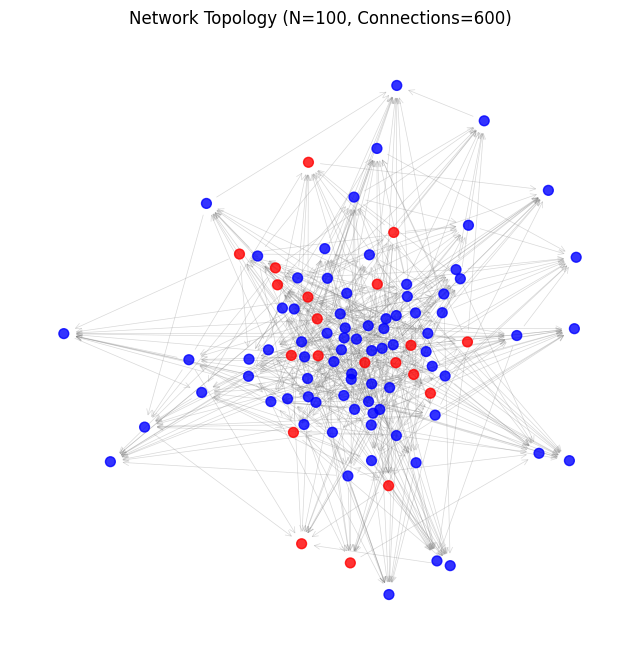

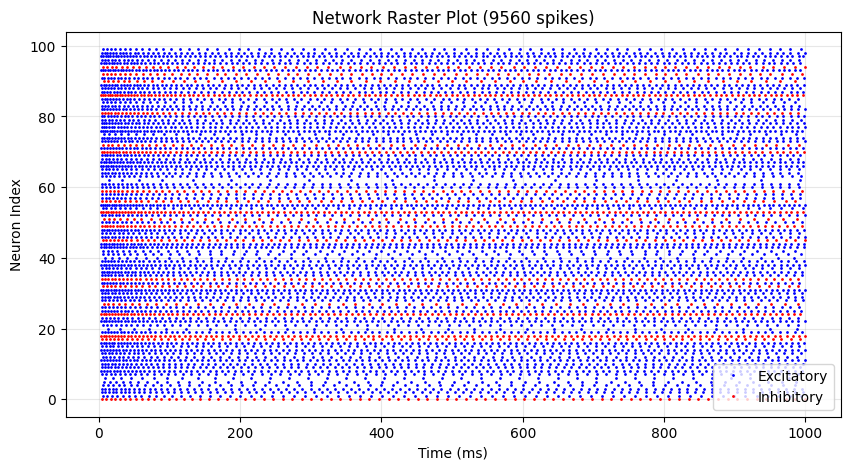

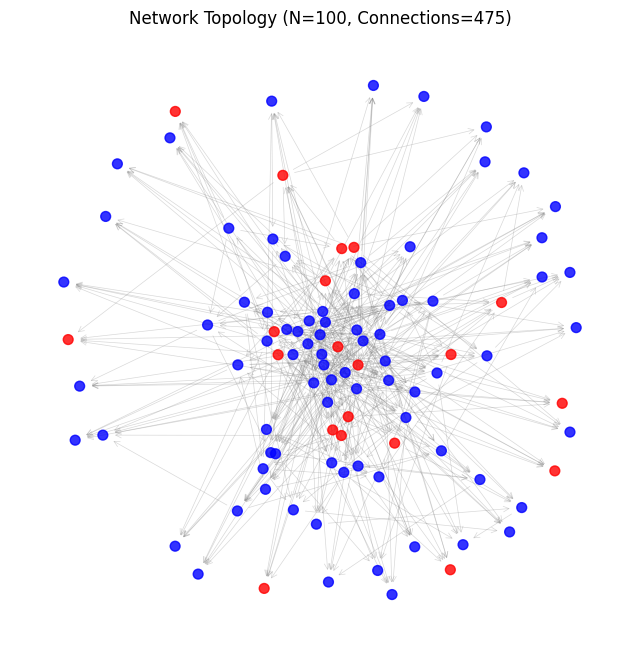

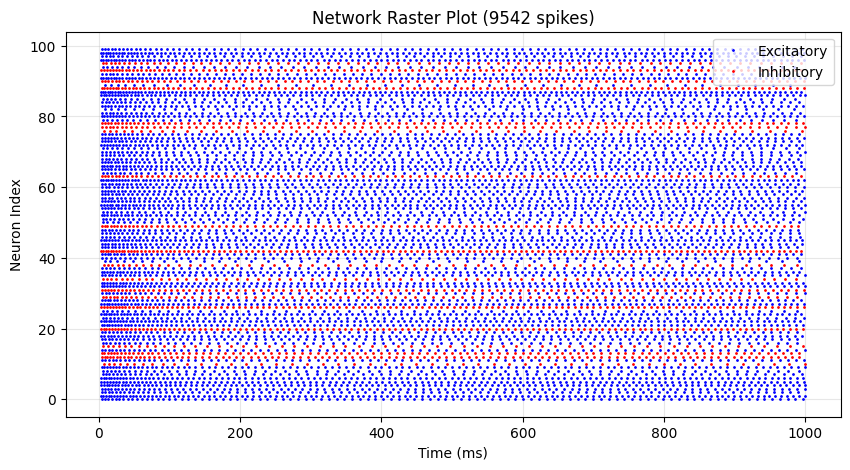

In [ ]:
# Neural network Simulator via Brian2
def simulate_network(edges, N=100, var_magn=0, duration_ms=1000):
  '''
  Simulates a network of AdExp IF neurons connected by the edges defined in the connectivity matrix.

  sources: https://brian2.readthedocs.io/en/stable/examples/frompapers.Brette_Gerstner_2005.html

  Returns raster plot of the network
  '''
  start_scope()

  # Parameters
  duration = duration_ms/1000*second
  sim_dt = 0.1*ms
  defaultclock.dt = sim_dt

  # Use of simple AdExp neurons, but other type of neurons (LIF, HH,Izhekevich, ML,etc.) would work same
  tau = 20*ms
  El = -70*mV
  Vt = -50*mV
  Vr = -60*mV
  R = 10*Mohm

  # Exci and Inhi population for regularization
  EI_coeff = np.clip(0.8 + np.random.uniform(-var_magn, var_magn),0.4,0.95)
  N_e = int(EI_coeff*N)
  N_i = int(N-N_e)

  # Neural parameters
  C = 281 * pF
  C = C + C*np.random.uniform(-var_magn, var_magn)
  gL = 30 * nS
  taum = C / gL
  EL = -70.6 * mV
  VT = -50.4 * mV
  DeltaT = 2 * mV
  Vcut = VT + 5 * DeltaT

  # Pick an electrophysiological behaviour
  tauw, a, b, Vr = 144*ms, 4*nS, 0.0805*nA, -70.6*mV # Regular spiking (as in the paper)
  #tauw,a,b,Vr=20*ms,4*nS,0.5*nA,VT+5*mV # Bursting
  #tauw,a,b,Vr=144*ms,2*C/(144*ms),0*nA,-70.6*mV # Fast spiking

  eqs = """
  dvm/dt = (gL*(EL - vm) + gL*DeltaT*exp((vm - VT)/DeltaT) + sensi*I - w)/C : volt
  dw/dt = (a*(vm - EL) - w)/tauw : amp
  I : amp
  sensi : 1
  """

  # Create Neuron Group
  model = {}
  model['N'] = NeuronGroup(N, model=eqs, threshold='vm>Vcut',reset="vm=Vr; w+=b", method='euler',name="N")
  model['N_exc'] = model['N'][:N_e]
  model['N_inh'] = model['N'][N_e:]


  # Initialize randomly
  model['N'].vm = 'EL + 0*(VT-EL)*rand()'
  model['N'].I = 1.95*nA + 1.5*nA*np.random.uniform(-var_magn, var_magn) # Constant background drive to make them fire
  model['N'].sensi = 1+0.2*np.random.randn(N_e+N_i) # add random variation in external stimulation

  # Neural Network: create synapses
  idx_exci = np.random.choice(range(N), size=N_e, replace=False)
  #idx_inhi = random.choice(range(N), size=N_i, replace=False)
  exci_edges = [e for e in edges if e[0] in idx_exci]
  inhi_edges = [e for e in edges if e[0] not in idx_exci]
  src_e = [e[0] for e in exci_edges]
  tgt_e = [e[1] for e in exci_edges]

  src_i = [e[0] for e in inhi_edges]
  tgt_i = [e[1] for e in inhi_edges]

  # Synapse model
  #synapse_model = "w : siemens"
  synapse_model = "w_syn : volt"

  # Excitatory synapses
  model['S_exc'] = Synapses(model['N'], model['N'],model=synapse_model, on_pre='vm += w_syn')
  if len(src_e) > 0:
    model['S_exc'].connect(i=src_e, j=tgt_e)
    model['S_exc'].delay = '(rand()**2)*5*ms'
    model['S_exc'].w_syn = '1.0*mV + 0.3*mV * rand()'
  else:
    model['S_exc'].active = False

  # Inhibitory synapses
  model['S_inh'] = Synapses(model['N'], model['N'],model=synapse_model, on_pre='vm -= w_syn')
  if len(src_i) > 0:
    model['S_inh'].connect(i=src_i, j=tgt_i)
    model['S_inh'].delay = '(rand()**2)*5*ms'
    model['S_inh'].w_syn = '1.5*mV + 0.3*mV * rand()'
  else:
    model['S_inh'].active = False


  model['spike_mon'] = SpikeMonitor(model['N'],name='spike_mon')

  # Simulation
  Net = Network(model)
  Net.run(duration, report=None)
  return Net['spike_mon'], idx_exci


def rasterplot_topology(model_idx=1,N=100):
  '''
  Raster plot visualization
  '''

  edges = generate_topology(model_idx=model_idx, N=N)
  spike_monitor, idx_exci= simulate_network(edges, N=N)

  # Plot graph network
  plot_network_graph(edges, N, idx_exci)


  # Plot rasterplot
  times = spike_monitor.t/ms
  indices = spike_monitor.i

  exc_mask = np.isin(indices, idx_exci)
  inh_mask = ~exc_mask

  plt.figure(figsize=(10, 5))
  plt.plot(times[exc_mask], indices[exc_mask], '.', color='blue', label='Excitatory', markersize=2)
  plt.plot(times[inh_mask], indices[inh_mask], '.', color='red', label='Inhibitory', markersize=2)

  plt.xlabel('Time (ms)')
  plt.ylabel('Neuron Index')
  plt.title(f'Network Raster Plot ({times.shape[0]} spikes)')
  plt.grid(True, alpha=0.3) # Optional: adds a faint grid
  plt.legend()
  plt.show()

rasterplot_topology(model_idx=0,N=100)
rasterplot_topology(model_idx=1,N=100)
rasterplot_topology(model_idx=2,N=100)
rasterplot_topology(model_idx=3,N=100)
rasterplot_topology(model_idx=4,N=100)
rasterplot_topology(model_idx=5,N=100)
rasterplot_topology(model_idx=6,N=100)
rasterplot_topology(model_idx=7,N=100)
rasterplot_topology(model_idx=8,N=100)

#### Use of ABC-RF to train/predict the model (newtork topology)

Now that each model/topology produce its internal activity (spike trains plotted via above raster plot), we can extract features (Summary statistics) which will be used by the ABC-RF model to predict which model produced the observed data

==>> Let's use Elephant built-in functions to extract peer-reviewed relevant features

In [ ]:
## Extract features
try:
  import neo
  import quantities as pq
  from brian2 import ms
  from elephant.statistics import mean_firing_rate, cv, isi, lv, fanofactor
  from elephant import statistics
  from elephant.conversion import BinnedSpikeTrain
  from elephant.spike_train_correlation import correlation_coefficient
except:
  !pip install elephant neo quantities
  import neo
  import quantities as pq
  from brian2 import ms
  from elephant.statistics import mean_firing_rate, cv, isi, lv, fanofactor
  from elephant import statistics
  from elephant.conversion import BinnedSpikeTrain
  from elephant.spike_train_correlation import correlation_coefficient

In [ ]:
#### Summary Statistics Calculator
def calc_network_stats(spike_mon, N, duration_ms):
  '''
  Calculates Summary Statistics
  We want to ompresses the complex raster plot into a few scalars/features
  to generate Summary Stats

  We use Elephant package: https://elephant.readthedocs.io/en/latest/modules.html
  '''

  spike_trains = []
  duration_qty = duration_ms * pq.ms

  # Extract spike dictionary
  brian_trains = spike_mon.spike_trains()

  for i in range(N):
    # Handle neurons that didn't spike
    times_brian = brian_trains.get(i, [])

    if len(times_brian) > 0:
      times_clean = times_brian / ms
    else:
      times_clean = []


    if len(times_brian) > 0:
      times_clean = times_brian / ms
    else:
      times_clean = []

    st = neo.SpikeTrain(times_clean, units=pq.ms, t_start=0*pq.ms, t_stop=duration_qty)
    spike_trains.append(st)


  # 1/ average Mean Firing Rate across neurons (Hz)
  rates = [mean_firing_rate(st).rescale(pq.Hz).magnitude for st in spike_trains]
  avg_rate = np.mean(rates)

  # 2/ Population Fano Factor (Dispersion of Rates)
  FF = fanofactor(spike_trains)

  # 3 & 4/ Coefficient of Variation (CV) of ISIs & Average Lv (Burstiness)
  cv_list = []
  lv_list = []
  for st in spike_trains:
    if len(st) > 2:
      intervals = isi(st)
      cv_list.append(cv(intervals))
      lv_list.append(lv(intervals))

  avg_cv = np.mean(cv_list) if len(cv_list) > 0 else 0.0
  avg_lv = np.mean(lv_list) if len(lv_list) > 0 else 0.0


  # 5/ Mean Pairwise Correlation (Synchrony)
  binned_st = BinnedSpikeTrain(spike_trains, bin_size=5*pq.ms)
  corr_matrix = correlation_coefficient(binned_st) # (N, N)

  upper_tri_indices = np.triu_indices(N, k=1) #  average of the upper triangle
  mean_corr = np.nanmean(corr_matrix[upper_tri_indices])
  if np.isnan(mean_corr): mean_corr = 0.0

  return np.array([avg_rate, FF, avg_cv, avg_lv, mean_corr])


In [ ]:
import time

#### Wrapper for Reference Table Generation
def generate_reference_table(N=100,duration_ms=500,n_simulations=50, var_magn=0):
  print(f"Generating Reference Table with {n_simulations} simulations...")
  X_ref = []
  y_ref = []

  tic = time.time()
  for i in range(n_simulations):
    model_idx = np.random.choice([0, 1, 2, 3])

    # Create the network topology
    edges = generate_topology(model_idx, N=N,var_magn=var_magn)
    # Simulate  the neural network activity
    spikes, _ = simulate_network(edges, N=N, duration_ms=duration_ms, var_magn=var_magn)

    # Compute Summary Statistics
    stats = calc_network_stats(spikes, N=N, duration_ms=duration_ms)

    X_ref.append(stats)
    y_ref.append(model_idx)

    if (i+1) % (n_simulations//10) == 0:
      toc = time.time()
      elapsed_time = toc - tic
      print(f"  Simulated {i+1}/{n_simulations}, Elapsed Time: {elapsed_time:.2f} seconds")
      tic = time.time()

  return np.array(X_ref), np.array(y_ref)



#### Observed data

Small variation of previous training data

In [ ]:

def generate_obs_data(model_idx, N=100, var_magn=0.1, n_simulations=1,duration_ms=500):
  '''
  Generate the observed dataset, which is a small deviation of trained data
  '''

  #### Generating Observed Table with {n_simulations} simulations
  X_ref = []
  y_ref = []

  for i in range(n_simulations):
    # Create the network topology
    edges = generate_topology(model_idx, N=N,var_magn=var_magn)
    # Simulate  the neural network activity
    spikes, _ = simulate_network(edges, N=N, duration_ms=duration_ms,var_magn=var_magn)


    # Compute Summary Statistics
    stats = calc_network_stats(spikes, N=N, duration_ms=duration_ms)

    X_ref.append(stats)
    y_ref.append(model_idx)

  return np.array(X_ref), np.array(y_ref)


### Observation of the summary statistics distribution

In [ ]:
def plot_feature_distributions(X, y, X_obs,y_obs, feature_names=None, model_labels=None):
  '''
  Plots the distribution (Histogram + KDE) of each feature separated by Model.
  '''
  if feature_names is None:
      feature_names = ['Mean Rate (Hz)', 'Fano Factor', 'Avg CV', 'Avg Lv', 'Mean Correlation']

  if model_labels is None:
      model_labels = {0: 'Random (ER)', 1: 'Rary-tree (RT)', 2: 'Complete Graph (CG)',3: 'Small-World (WS)'}
      model_labels_obs = {0: 'Observed (ER)', 1: 'Observed (RT)', 2: 'Observed (BA)', 3: ' Observed (WS)'}
      #model_labels = {0: 'A', 1: 'B', 2: 'C',3: 'D', 4: 'E', 5: 'F',6: 'G', 7: 'H', 8: 'I'}
      #model_labels_obs = {0: 'A', 1: 'B', 2: 'C',3: 'D', 4: 'E', 5: 'F',6: 'G', 7: 'H', 8: 'I'}
  obs_label_name = "Observed Data"

  n_features = X.shape[1]
  n_obs_samples = X_obs.shape[0]

  # DataFrame for easier plotting with Seaborn
  df_train = pd.DataFrame(X, columns=feature_names)
  df_train['Model'] = [model_labels[label] for label in y]
  df_train['Dataset'] = 'Training'

  df_obs = pd.DataFrame(X_obs, columns=feature_names)
  df_obs['Model'] = [model_labels_obs[label] for label in y_obs]
  df_obs['Dataset'] = 'Observed'


  # Create subplots
  fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 5))
  if n_features == 1: axes = [axes]

  # Plot each feature
  palette = sns.color_palette("bright", len(model_labels))
  # Map model names to colors
  model_names = [model_labels[i] for i in sorted(model_labels.keys())]
  color_map = dict(zip(model_names, palette))
  obs_color = 'black'

  for i, feature in enumerate(feature_names):
      ax = axes[i]

      # Plot Histogram with Kernel Density Estimate (KDE)
      sns.histplot(data=df_train, x=feature, hue='Model', element="step", stat="density", common_norm=False, kde=True, ax=ax, palette=palette, alpha=0.3)
      #sns.kdeplot(data=df_train, x=feature, hue='Type', palette=palette, fill=True, alpha=0.3, linewidth=0, ax=ax, common_norm=False)
      if True:
        sns.histplot(data=df_obs, x=feature, element="step", stat="density", common_norm=False, kde=True, ax=ax, color=obs_color, alpha=0.5)
        #sns.kdeplot(data=df_obs, x=feature, color=obs_color, linewidth=2.5, linestyle='--',ax=ax, label=obs_label_name)
      else:
        for j in range(n_obs_samples):
          obs_val = X_obs[j, i]
          true_model_idx = y_obs[j]
          line_color = palette[true_model_idx]
          ax.axvline(x=obs_val, color=line_color, linestyle='--', linewidth=2, label='Observed' if j == 0 else "")

          ylim = ax.get_ylim()
          ax.scatter(obs_val, ylim[1]*0.95, color=line_color, marker='v', s=100, zorder=10, edgecolor='black')


      ax.set_title(feature, fontsize=11, fontweight='bold')
      ax.set_xlabel(feature)
      ax.set_ylabel('Density')

      # Only show legend on the first plot to avoid clutter
      # Clean up legends: Only keep the main legend on the first plot
      if i == 0:
        legend_handles = []
        for name, color in color_map.items():
            patch = mpatches.Patch(color=color, label=name, alpha=0.6)
            legend_handles.append(patch)

        # Create handle for Observed Data
        obs_patch = mpatches.Patch(color=obs_color, label=df_obs['Model'][0], alpha=0.4)
        legend_handles.append(obs_patch)

        # Add Legend
        ax.legend(handles=legend_handles, loc='upper right', title="Dataset")
      else:
        ax.get_legend().remove()

  if False:
    handles, labels = axes[0].get_legend_handles_labels()
    obs_line = mlines.Line2D([], [], color='black', linestyle='--', label='Observed Data')
    axes[0].legend(handles=handles + [obs_line], labels=labels + ['Observed Data'], loc='upper right')

  plt.tight_layout()
  plt.show()


##### Important:
Because in neuroscience, raster plot are easy-ish to obtain from a same population, but are known to be noisy, we can collect several data point of the same population/network to get a more confident ABC-RF prediction. That's why the function `generate_obs_data` has the option `n_simulations`, returning several data point of the same model

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


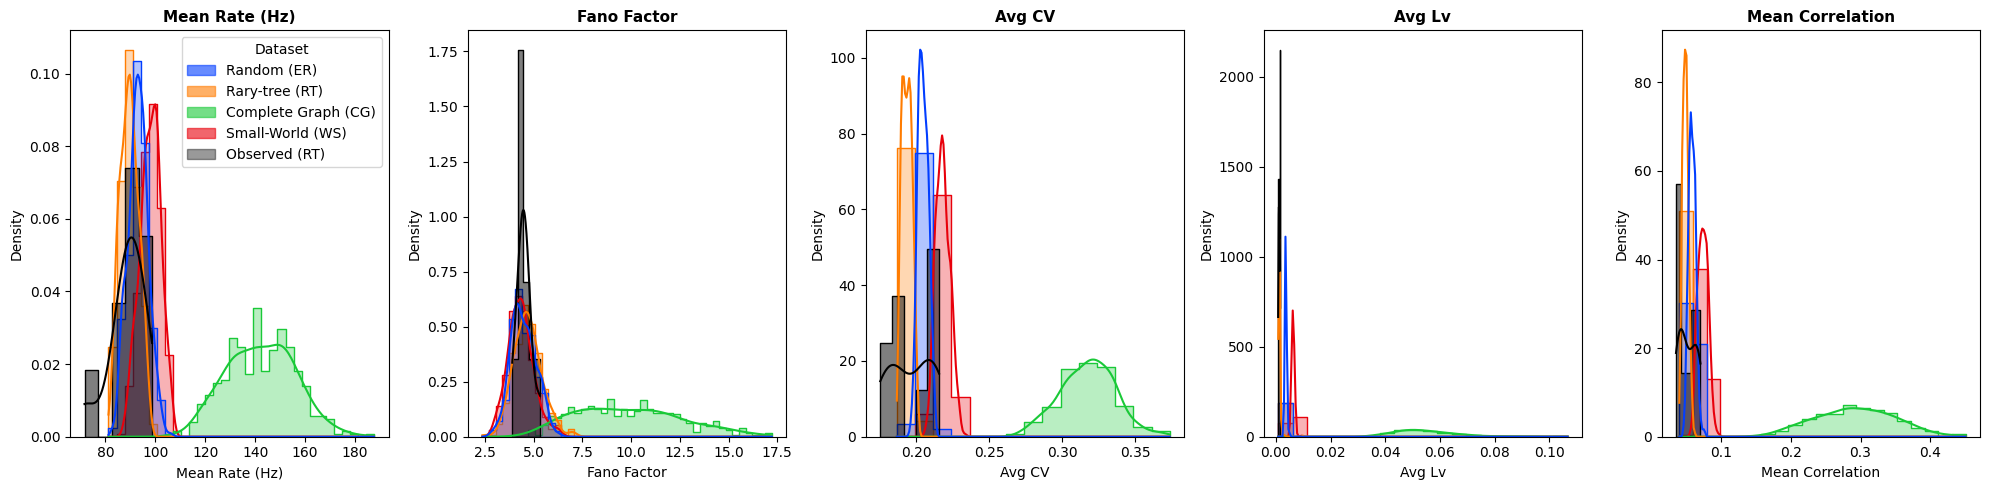

Predicted Model: 1 (True was [1 1 1 1 1 1 1 1 1 1]), rate agreement = 0.70 Posterior Probability = [1.    1.    1.    1.    0.648 0.578 0.998 1.    0.768 1.   ]


In [ ]:
import os
import pickle
from google.colab import drive

# Training data
seeed = 13
duration_ms = 800
loading = True

drive.mount('/content/drive')
data_file_path = '/content/drive/MyDrive/CompStats_dataset_v1.pkl' #v1 has 1500 samples, v2 has 150 samples
if os.path.exists(data_file_path) and loading:
  with open(data_file_path, 'rb') as f:
    X_ref, y_ref, X_obs, y_obs = pickle.load(f)
else:
  # Training data
  set_seed(seeed+1)
  X_ref, y_ref = generate_reference_table(N=100,duration_ms=duration_ms,n_simulations=1500,var_magn=0.05)

  # Observed data
  set_seed(seeed+2)
  X_obs,y_obs = generate_obs_data(model_idx=1, N=100, var_magn=0.2, n_simulations=10,duration_ms=duration_ms)


  with open(data_file_path, 'wb') as f:
    pickle.dump((X_ref, y_ref, X_obs, y_obs), f)
  print("Save complete.")




if True:
  # plot histogram distribution of training data
  plot_feature_distributions(X_ref, y_ref,X_obs,y_obs)



rf_model, lda = train_ABCRF_classifier(X_ref, y_ref)
rf_reg = train_error_rf_regressor(X_ref, y_ref, rf_model, lda, n_trees=n_trees, seed=13)


selected_model, votes, rate_agreement = predict_ABCRF_classifier(rf_model, lda, X_obs)
posterior_prob = estimate_posterior_probability(rf_model, rf_reg, lda, X_obs)
print(f"Predicted Model: {selected_model} (True was {y_obs}), rate agreement = {rate_agreement:.2f} Posterior Probability = {posterior_prob}")


#### Stat test

In [ ]:
if False:
  accuracy = 0
  n_test = 30
  for itest in range(n_test):
    set_seed(seeed+itest)
    X_obs,y_obs = generate_obs_data(model_idx=itest%4, N=100, var_magn=0.15, n_simulations=1,duration_ms=duration_ms)
    selected_model, votes, rate_agreement = predict_ABCRF_classifier(rf_model, lda, X_obs)
    print(f"Predicted Model: {selected_model} (True was {y_obs}), rate agreement = {rate_agreement:.2f}")
    if selected_model == y_obs:
      accuracy += 1
  print(f"\n \n Accuracy: {accuracy/n_test}")

# Models comparison

We want to compare standard ABC / ABC-RF / MCMC-ABC

In [ ]:
import time

n_test = 50
n_models, RF, KNN, MCMC = 3, 0, 1, 2
accuracy = np.zeros((n_test, n_models))
posterior = np.zeros((n_test, n_models))
agreement = np.zeros((n_test, n_models))
timing    = np.zeros((n_test, n_models))


for itest in range(n_test):
  global_tic = time.time()
  set_seed(seeed+itest)
  X_obs,y_obs = generate_obs_data(model_idx=itest%4, N=100, var_magn=0.15, n_simulations=5,duration_ms=duration_ms)


  # ---------- ABC-RF ----------
  tic = time.perf_counter()
  selected_model_rf, votes, rate_agreement_rf = predict_ABCRF_classifier(rf_model, lda, X_obs)
  posterior_prob_rf = estimate_posterior_probability(rf_model, rf_reg, lda, X_obs)

  timing[itest, RF] = time.perf_counter() - tic
  accuracy[itest, RF] = (selected_model_rf == int(np.mean(y_obs)))
  posterior[itest, RF] = np.mean(posterior_prob_rf)
  agreement[itest, RF] = rate_agreement_rf


  # ---------- ABC-kNN ----------
  tic = time.perf_counter()
  selected_model_knn, posterior_probs_knn, rate_agreement_knn = ABC_knn_algo(X_ref, y_ref, X_obs)

  timing[itest, KNN] = time.perf_counter() - tic
  accuracy[itest, KNN] = (selected_model_knn == int(np.mean(y_obs)))
  posterior[itest, KNN] = posterior_probs_knn[selected_model_knn]
  agreement[itest, KNN] = rate_agreement_knn # actually not relevant

  # ---------- ABC-MCMC ----------
  tic = time.perf_counter()
  selected_model_mcmc, posterior_probs_mcmc, rate_agreement_mcmc = ABC_MCMC_algo(X_ref, y_ref, X_obs)

  timing[itest, MCMC] = time.perf_counter() - tic
  accuracy[itest, MCMC] = (selected_model_mcmc == int(np.mean(y_obs)))
  posterior[itest, MCMC] = posterior_probs_mcmc[selected_model_mcmc]
  agreement[itest, MCMC] = rate_agreement_mcmc # actually not relevant

  if itest < 5:
    print(f"iteration took {time.time()-global_tic:.2f} seconds")


model_names = ["ABC-RF", "ABC-kNN", "ABC-MCMC"]

for i, name in enumerate(model_names):
  print(f"\n{name}")
  print(f"Accuracy: {accuracy[:, i].mean():.3f}")
  print(f"Mean posterior: {posterior[:, i].mean():.3f}")
  print(f"Mean agreement: {agreement[:, i].mean():.3f}")

iteration took 11.72 seconds
iteration took 11.44 seconds
iteration took 13.35 seconds
iteration took 11.57 seconds
iteration took 11.81 seconds
iteration took 10.53 seconds
iteration took 11.78 seconds
iteration took 11.56 seconds
iteration took 11.63 seconds
iteration took 11.38 seconds
iteration took 12.09 seconds
iteration took 10.74 seconds
iteration took 11.10 seconds
iteration took 11.40 seconds
iteration took 11.61 seconds
iteration took 11.62 seconds
iteration took 11.91 seconds


WARNING    /usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
 [py.warnings]
  c /= stddev[:, None]

WARNING    /usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
 [py.warnings]
  c /= stddev[None, :]



iteration took 10.87 seconds
iteration took 11.56 seconds
iteration took 11.32 seconds
iteration took 11.47 seconds
iteration took 11.51 seconds
iteration took 11.38 seconds
iteration took 10.69 seconds
iteration took 11.53 seconds
iteration took 11.31 seconds
iteration took 11.77 seconds
iteration took 11.73 seconds
iteration took 11.14 seconds
iteration took 10.87 seconds
iteration took 11.95 seconds
iteration took 11.75 seconds
iteration took 12.98 seconds
iteration took 11.64 seconds
iteration took 12.38 seconds


WARNING    /usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
 [py.warnings]
  c /= stddev[:, None]

WARNING    /usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
 [py.warnings]
  c /= stddev[None, :]



iteration took 11.54 seconds
iteration took 11.14 seconds
iteration took 11.61 seconds
iteration took 11.93 seconds
iteration took 11.96 seconds
iteration took 12.23 seconds
iteration took 11.90 seconds
iteration took 11.45 seconds
iteration took 11.47 seconds
iteration took 11.59 seconds
iteration took 11.47 seconds
iteration took 11.94 seconds
iteration took 12.11 seconds
iteration took 11.42 seconds
iteration took 10.61 seconds
iteration took 11.80 seconds
iteration took 11.59 seconds
iteration took 11.73 seconds
iteration took 11.81 seconds
iteration took 12.21 seconds
iteration took 11.08 seconds
iteration took 11.82 seconds
iteration took 11.60 seconds
iteration took 12.04 seconds
iteration took 11.84 seconds
iteration took 11.99 seconds
iteration took 11.61 seconds
iteration took 11.54 seconds
iteration took 11.64 seconds
iteration took 11.72 seconds
iteration took 11.64 seconds
iteration took 12.25 seconds
iteration took 12.19 seconds
iteration took 12.03 seconds
iteration took

WARNING    /usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
 [py.warnings]
  c /= stddev[:, None]

WARNING    /usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
 [py.warnings]
  c /= stddev[None, :]



iteration took 12.23 seconds
iteration took 12.49 seconds


WARNING    /usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
 [py.warnings]
  c /= stddev[:, None]

WARNING    /usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
 [py.warnings]
  c /= stddev[None, :]



iteration took 12.48 seconds
iteration took 12.77 seconds
iteration took 12.13 seconds

ABC-RF
Accuracy: 0.980
Mean posterior: 0.953
Mean agreement: 0.856

ABC-kNN
Accuracy: 0.460
Mean posterior: 0.371
Mean agreement: 0.786

ABC-MCMC
Accuracy: 0.770
Mean posterior: 0.572
Mean agreement: 0.666


WARNING    /tmp/ipython-input-3365058652.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
 [py.warnings]
  plt.boxplot(



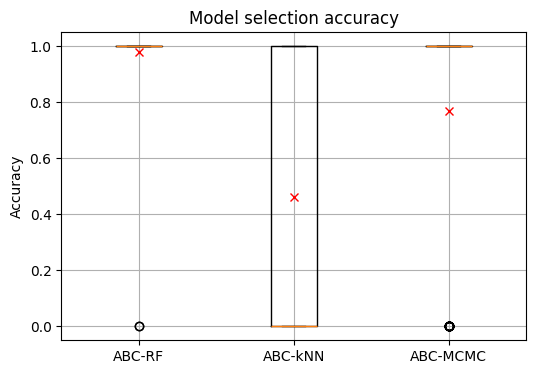

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(
    accuracy,
    labels=model_names,
    showmeans=True,
    meanprops=dict(marker='x', markerfacecolor='black', markeredgecolor='red')
)
plt.ylabel("Accuracy")
plt.title("Model selection accuracy")
plt.grid(True)
plt.show()


WARNING    /tmp/ipython-input-1373406747.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
 [py.warnings]
  plt.boxplot(



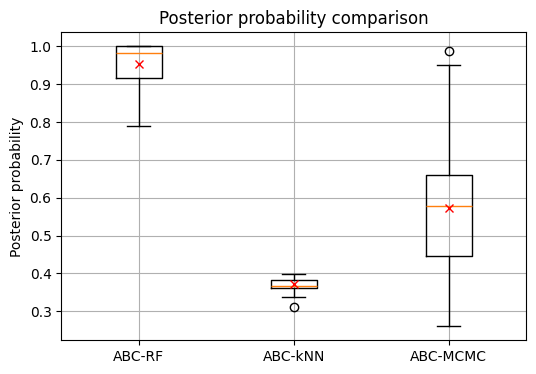

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(
    posterior,
    labels=model_names,
    showmeans=True,
    meanprops=dict(marker='x', markerfacecolor='black', markeredgecolor='red')
)
plt.ylabel("Posterior probability")
plt.title("Posterior probability comparison")
plt.grid(True)
plt.show()


WARNING    /tmp/ipython-input-2690817762.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(agreement, labels=model_names)
 [py.warnings]
  plt.boxplot(agreement, labels=model_names)



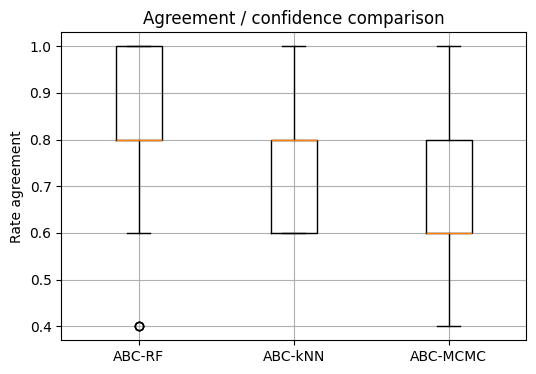

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(agreement, labels=model_names)
plt.ylabel("Rate agreement")
plt.title("Agreement / confidence comparison")
plt.grid(True)
plt.show()


In [ ]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(accuracy[:, RF], accuracy[:, KNN])
print("RF vs kNN accuracy p-value:", p)
stat, p = wilcoxon(accuracy[:, RF], accuracy[:, MCMC])
print("RF vs MCMC accuracy p-value:", p)
stat, p = wilcoxon(accuracy[:, KNN], accuracy[:, MCMC])
print("KNN vs MCMC accuracy p-value:", p)

RF vs kNN accuracy p-value: 3.684265188407034e-12
RF vs MCMC accuracy p-value: 1.1933310815418253e-05
KNN vs MCMC accuracy p-value: 4.02481862389776e-05


WARNING    /tmp/ipython-input-2099235682.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
 [py.warnings]
  plt.boxplot(



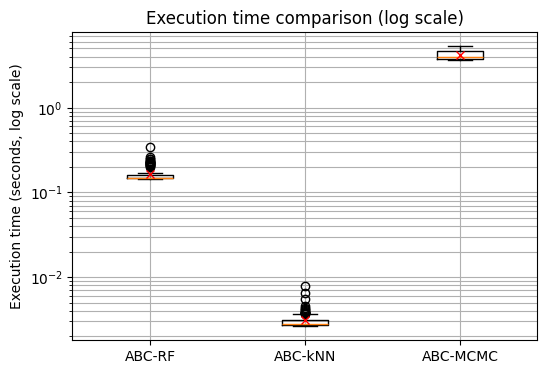

In [ ]:
model_names = ["ABC-RF", "ABC-kNN", "ABC-MCMC"]

plt.figure(figsize=(6, 4))
plt.boxplot(
    timing,
    labels=model_names,
    showmeans=True,
    meanprops=dict(marker='x', markerfacecolor='black', markeredgecolor='red')
)
plt.yscale("log")
plt.ylabel("Execution time (seconds, log scale)")
plt.title("Execution time comparison (log scale)")
plt.grid(True, which="both")
plt.show()




In [ ]:
sys.exit()

SystemExit: 

WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
 [py.warnings]
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)



In [ ]:
accuracy = 0
n_test = 100
for itest in range(n_test):
  set_seed(seeed+itest)
  X_obs,y_obs = generate_obs_data(model_idx=itest%4, N=100, var_magn=0.15, n_simulations=10,duration_ms=duration_ms)
  selected_model, votes, rate_agreement = predict_ABCRF_classifier(rf_model, lda, X_obs)
  print(f"Predicted Model: {selected_model} (True was {y_obs}), rate agreement = {rate_agreement:.2f}")
  if selected_model == int(np.mean(y_obs)):
    accuracy += 1
print(f"\n \n Accuracy: {accuracy/n_test}")